# Sustainability Report Analysis using Natural Language Processing (NLP)

## Erasmus+ Traineeship – University of Cantabria

### Project
**Data Science Support for Sustainability Analysis in the Agri-food Sector**

### Supervisor
**Dr. Elisa Baraibar Díez**

### Student
**Ranim Hfaiedh**

---

## Objective of this notebook

This notebook analyses the textual content of sustainability-related documents collected from large agri-food companies. Using Natural Language Processing (NLP) techniques, the documents are processed to identify the most frequent sustainability terms, thematic patterns, and key sustainability topics. The results complement the exploratory and statistical analyses presented in the previous notebooks and provide deeper insights into corporate sustainability communication.

In [1]:
from wordcloud import WordCloud

print("WordCloud works!")

WordCloud works!


# 1. Import Libraries

The following libraries are required for PDF processing, text cleaning, Natural Language Processing (NLP), visualization, and topic modelling.

In [2]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 27.5 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


In [4]:
import os
import zipfile
import re
import string

import pandas as pd
import numpy as np

# PDF extraction
import pdfplumber

# NLP
import nltk
from nltk.corpus import stopwords

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Sentiment Analysis
from textblob import TextBlob

# 2. Download NLP Resources

The Natural Language Toolkit (NLTK) provides predefined stopword lists that will be used during text preprocessing. Since the sustainability reports are written in both English and Spanish, stopwords from both languages will be downloaded.

In [5]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# 3. Upload Sustainability Reports

The sustainability-related documents are uploaded as a compressed ZIP archive. The archive contains sustainability reports together with a small number of supplementary documents such as policies and spreadsheets.

In [6]:
import os

print(os.listdir("/content"))


['.config', 'DATABASE (2).xlsx', 'sustainability reports_ (3).zip', 'sample_data']


In [7]:
import os

zip_path = "/content/sustainability reports_ (3).zip"

print("Exists:", os.path.exists(zip_path))
print("Size (bytes):", os.path.getsize(zip_path))

Exists: True
Size (bytes): 1262172849


# 4. Extract Sustainability Documents

The uploaded ZIP archive is extracted into the Colab working directory to allow automatic access to all documents included in the analysis.

In [8]:
import zipfile
import shutil
import os

zip_path = "/content/sustainability reports_ (3).zip"
extract_path = "/content/sustainability_reports"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

print("✅ Extraction completed!")

✅ Extraction completed!


# 5. Verify Extracted Files

After extracting the ZIP archive, the contents are checked to ensure that all sustainability-related documents are available for analysis. This verification step confirms that the extraction process was successful before proceeding with PDF text extraction.

In [9]:
import os

extract_path = "/content/sustainability_reports"

pdf_files = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(".pdf"):
            pdf_files.append(os.path.join(root, file))

print("Number of PDF files:", len(pdf_files))

print("\nFirst 10 PDFs:")
for pdf in pdf_files[:10]:
    print(pdf)

Number of PDF files: 126

First 10 PDFs:
/content/sustainability_reports/sustainability reports_/certificados-iberfruta-2025.pdf
/content/sustainability_reports/sustainability reports_/sus rapport company uvesa.pdf
/content/sustainability_reports/sustainability reports_/sus report famadesa.pdf
/content/sustainability_reports/sustainability reports_/sus report company sovena.pdf
/content/sustainability_reports/sustainability reports_/sus report company capsa.pdf
/content/sustainability_reports/sustainability reports_/sus report company noel.pdf
/content/sustainability_reports/sustainability reports_/sus report monells.pdf
/content/sustainability_reports/sustainability reports_/sus report refresco.pdf
/content/sustainability_reports/sustainability reports_/sus report cidacos.pdf
/content/sustainability_reports/sustainability reports_/sus report company gullon.pdf


# 6. Extract Text from Sustainability Reports

The textual content of each PDF document is extracted using the `pdfplumber` library. Each document is processed page by page, and the extracted text is stored together with the company name and the original file name in a structured dataframe. This dataframe will serve as the basis for all subsequent Natural Language Processing (NLP) analyses.

In [10]:
import os
import pdfplumber
import pandas as pd

documents = []

for pdf_path in pdf_files:

    text = ""

    try:
        with pdfplumber.open(pdf_path) as pdf:

            for page in pdf.pages:

                page_text = page.extract_text()

                if page_text:
                    text += page_text + "\n"

    except Exception as e:
        print(f"Error reading {os.path.basename(pdf_path)}: {e}")

    documents.append({
        "Company": os.path.splitext(os.path.basename(pdf_path))[0],
        "File Name": os.path.basename(pdf_path),
        "Text": text
    })

documents_df = pd.DataFrame(documents)

print("Number of PDF documents:", len(documents_df))

documents_df.head()

Number of PDF documents: 126


,Company,File Name,Text
0,certificados-iberfruta-2025,certificados-iberfruta-2025.pdf,IFS Certificate\nIFS-2009/0007\nHerewith the c...
1,sus rapport company uvesa,sus rapport company uvesa.pdf,RESULTADOS ASPECTOS AMBIENTALES SIGNIFICATIVOS...
2,sus report famadesa,sus report famadesa.pdf,
3,sus report company sovena,sus report company sovena.pdf,SUSTAINABILITY\nREPORT 2025\nNURTURING\nFORWAR...
4,sus report company capsa,sus report company capsa.pdf,"Memoria de\nTriple\nImpacto\n2024\nAlcanzamos,..."


# 7. Assess the Extracted Text

Before performing Natural Language Processing (NLP), the extracted documents are evaluated to determine the amount of textual information available. The number of words contained in each document is calculated, allowing the identification of empty documents and providing an overview of the distribution of document lengths.

In [11]:
print(documents_df.columns.tolist())

['Company', 'File Name', 'Text']


In [12]:
# Count the number of words in each document
documents_df["Word Count"] = documents_df["Text"].apply(
    lambda x: len(str(x).split())
)

print("Total PDF documents:", len(documents_df))
print("Documents containing text:", (documents_df["Word Count"] > 0).sum())
print("Empty documents:", (documents_df["Word Count"] == 0).sum())

documents_df["Word Count"].describe()

Total PDF documents: 126
Documents containing text: 105
Empty documents: 21


,Word Count
count,126.000000
mean,17783.420635
std,21418.211736
min,0.000000
25%,1289.250000
50%,12303.000000
75%,24781.000000
max,115035.000000


### Interpretation

A total of 126 PDF documents were processed. Among them, 105 contained extractable textual information, while 21 documents returned no text. These empty documents are likely scanned PDFs or image-based files that cannot be processed using standard text extraction methods. The extracted corpus therefore provides a substantial textual dataset suitable for subsequent Natural Language Processing analyses.

# 8. Distribution of Document Length

The number of words extracted from each document is visualized to examine the distribution of document lengths. This provides an overview of the variability in the size of sustainability-related documents before applying Natural Language Processing techniques.

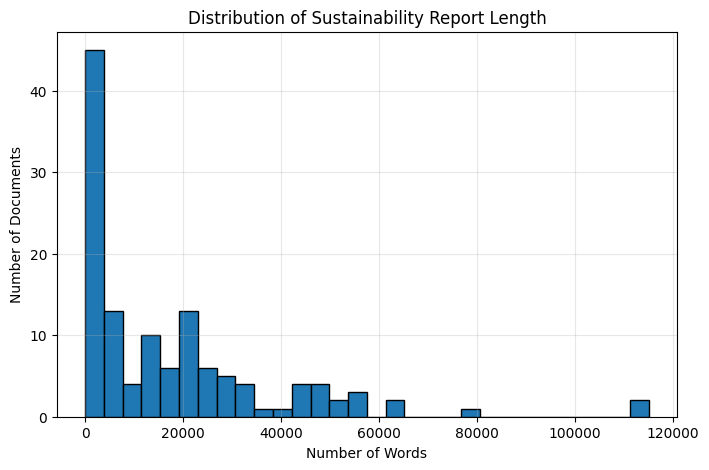

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    documents_df["Word Count"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Sustainability Report Length")

plt.xlabel("Number of Words")

plt.ylabel("Number of Documents")

plt.grid(alpha=0.3)

plt.show()


The histogram illustrates the distribution of sustainability report lengths measured by the number of extracted words. The distribution is positively skewed (right-skewed), indicating that most sustainability reports contain relatively few words, while a small number of reports are substantially longer. This demonstrates considerable variability in reporting practices across companies. The presence of several very long reports creates a long right tail, suggesting that some organizations provide much more detailed sustainability disclosures than others.

## 9. Text Preprocessing

Before applying Natural Language Processing techniques, the extracted text is cleaned to remove unnecessary elements that do not contribute to semantic analysis. The preprocessing pipeline converts all text to lowercase, removes punctuation, numbers, and common stopwords in both English and Spanish, and eliminates extra whitespace. This step produces a standardized corpus suitable for subsequent analyses such as word frequency analysis, word clouds, TF-IDF, topic modelling, and sentiment analysis.

In [15]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [16]:
import re
import string
import pandas as pd
from nltk.corpus import stopwords

# English and Spanish stopwords
english_stopwords = set(stopwords.words("english"))
spanish_stopwords = set(stopwords.words("spanish"))
all_stopwords = english_stopwords.union(spanish_stopwords)

def clean_text(text):

    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # Remove stopwords
    words = [
        word for word in text.split()
        if word not in all_stopwords
    ]

    return " ".join(words)

# Apply cleaning
documents_df["Clean_Text"] = documents_df["Text"].apply(clean_text)

# Preview
documents_df[["Text", "Clean_Text"]].head()

,Text,Clean_Text
0,IFS Certificate\nIFS-2009/0007\nHerewith the c...,ifs certificate ifs herewith certification bod...
1,RESULTADOS ASPECTOS AMBIENTALES SIGNIFICATIVOS...,resultados aspectos ambientales significativos...
2,,
3,SUSTAINABILITY\nREPORT 2025\nNURTURING\nFORWAR...,sustainability report nurturing forward sustai...
4,"Memoria de\nTriple\nImpacto\n2024\nAlcanzamos,...",memoria triple impacto alcanzamos nuevo hito c...


# 10. Word Frequency Analysis

## Objective

After cleaning the text, the next step is to identify the most frequently occurring words across all sustainability reports.

Word frequency analysis provides an initial understanding of the dominant vocabulary used by companies in their sustainability disclosures. It helps identify recurring themes, commonly discussed sustainability topics, and the language that characterizes the corpus.

The analysis is performed on the cleaned text, where punctuation, stopwords, and irrelevant terms have already been removed.

In [18]:
from collections import Counter

# Combine all cleaned documents into one text
all_words = " ".join(documents_df["Clean_Text"]).split()

print("Total words:", len(all_words))

Total words: 1792472


In [19]:
# Count word frequencies
word_counts = Counter(all_words)

# Create a dataframe of the 20 most frequent words
top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

top_words

,Word,Frequency
0,cid,524423
1,•,5398
2,–,4396
3,group,3961
4,total,3843
5,grupo,3698
6,gri,3640
7,sustainability,3490
8,water,3354
9,report,3113


In [27]:
extra_stopwords = {
    "report", "reports",
    "group", "grupo",
    "total",
    "gri",
    "cid",
    "memoria",
    "informe",
    "sustainability",
    "sostenibilidad",
    "company",
    "companies",
    "corporate",
    "annual",
    "2024",
    "2025",
    "ifs",
    "year",
    "statement",
    "information",
    "material",
    "general",
    "including",
    "program",
    "plan"
}

def remove_extra_stopwords(text):
    words = [
        word for word in text.split()
        if word not in extra_stopwords
    ]
    return " ".join(words)

documents_df["Clean_Text"] = documents_df["Clean_Text"].apply(remove_extra_stopwords)

In [28]:
documents_df["Clean_Text"] = documents_df["Clean_Text"].apply(
    lambda text: " ".join(
        word for word in text.split()
        if word.isalpha() and len(word) > 2
    )
)

In [22]:
documents_df["Clean_Text"].isna().sum()

np.int64(0)

In [29]:
all_words = " ".join(documents_df["Clean_Text"]).split()

word_counts = Counter(all_words)

top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

top_words

,Word,Frequency
0,water,3354
1,food,3059
2,social,3035
3,management,2954
4,gestión,2727
5,impact,2706
6,value,2662
7,business,2575
8,chain,2532
9,products,2421


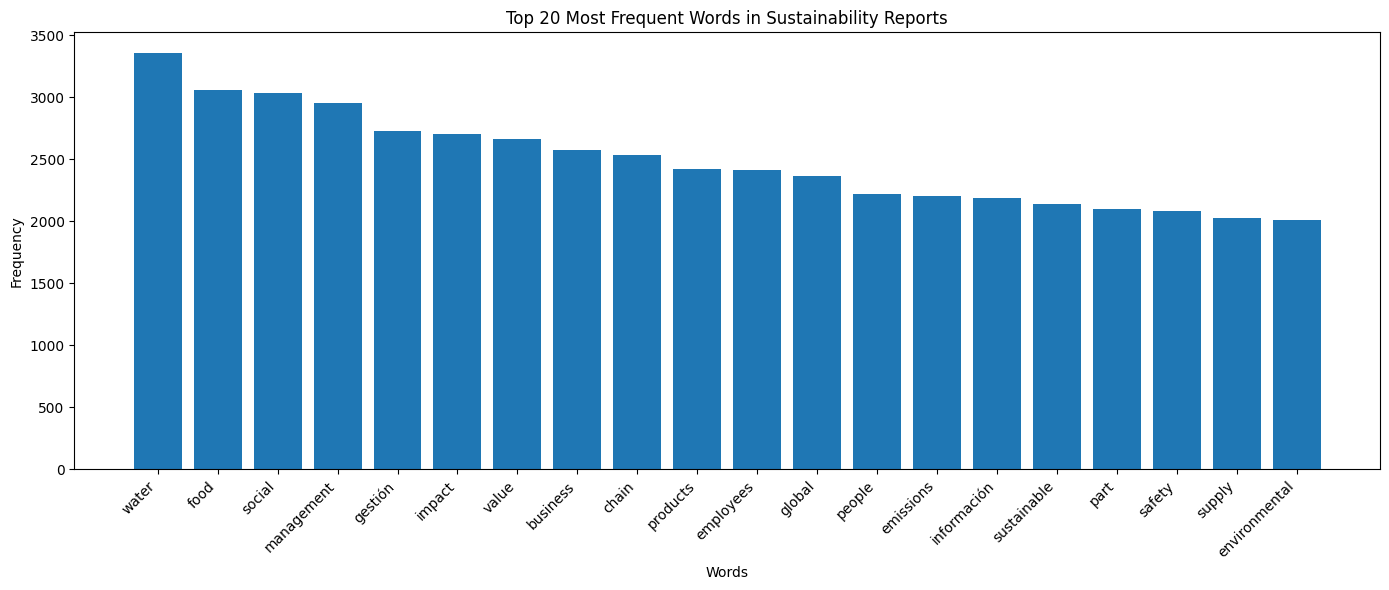

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(top_words["Word"], top_words["Frequency"])

plt.xticks(rotation=45, ha="right")

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words in Sustainability Reports")

plt.tight_layout()

plt.show()

The word frequency analysis highlights the most common terms appearing across the sustainability reports after preprocessing and the removal of generic report-related words. Environmental terms such as water, emissions, and impact, together with social and governance-related terms including employees, management, business, and people, dominate the corpus. This indicates that the collected reports primarily focus on environmental management, social responsibility, and corporate governance, reflecting the core dimensions of sustainability reporting. The presence of both English and Spanish terms also confirms the multilingual nature of the dataset.

# 11. Word Cloud

## Objective

The word cloud provides a visual representation of the most frequent words appearing across the sustainability reports. Words with higher frequencies are displayed in larger font sizes, allowing for a quick identification of the dominant sustainability topics discussed by the companies.

In [25]:
!pip install wordcloud

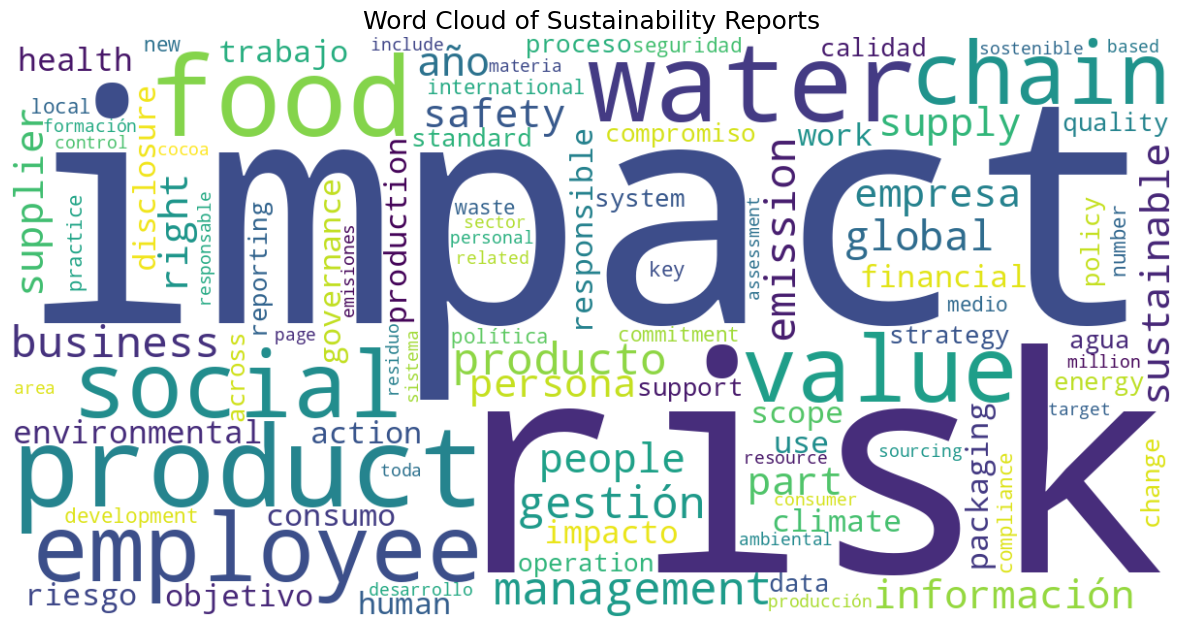

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned documents
text = " ".join(documents_df["Clean_Text"])

# Generate the word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100,
    collocations=False
).generate(text)

# Display
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Sustainability Reports", fontsize=18)

plt.show()

In [35]:
extra_stopwords = {
    "general",
    "global",
    "information",
    "value",
    "business",
    "products",
    "product",
    "program",
    "plan",
    "part",
    "use"
}

documents_df["Clean_Text"] = documents_df["Clean_Text"].apply(
    lambda text: " ".join(
        word for word in text.split()
        if word not in extra_stopwords
    )
)

### Interpretation

The word cloud provides a visual summary of the most frequent terms extracted from the sustainability reports after preprocessing. Larger words correspond to higher frequencies, indicating the dominant themes discussed across the corpus. Terms such as impact, water, social, employees, management, food, and emissions emphasize the importance of environmental management, social responsibility, supply chains, and corporate governance within sustainability reporting. The presence of both English and Spanish terms also reflects the multilingual nature of the dataset.

# 12. TF-IDF Analysis

## Objective

Unlike simple word frequency analysis, TF-IDF identifies the most important words within each sustainability report by considering both their frequency in a document and their rarity across the entire corpus. This helps identify terms that characterize individual reports rather than common words shared by all companies.

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Create the TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=100,
    min_df=2
)
# Fit and transform the cleaned documents
tfidf_matrix = vectorizer.fit_transform(documents_df["Clean_Text"])

# Convert to DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_df.head()

,across,agriculture,agua,also,ambiental,approach,así,año,años,based,...,suppliers,supply,support,sustainable,trabajo,training,través,waste,water,work
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.020921,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.233031,0.000000,0.000000,0.877902,0.250829,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.115352,0.029559,0.000000,0.083281,0.000000,0.070866,0.000000,0.000000,0.000000,0.069894,...,0.136736,0.050788,0.065713,0.13363,0.000000,0.071925,0.000000,0.059915,0.190996,0.066756
4,0.000000,0.000000,0.058517,0.000000,0.101843,0.000000,0.183348,0.234191,0.064776,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.154331,0.000000,0.270198,0.004825,0.000000,0.000000


In [37]:
# Calculate the average TF-IDF score for each term
mean_tfidf = tfidf_df.mean().sort_values(ascending=False)

mean_tfidf

,0
gestión,0.097541
productos,0.090965
personas,0.074471
calidad,0.067131
water,0.066552
...,...
reporting,0.018296
number,0.017957
board,0.017414
nestlé,0.013566


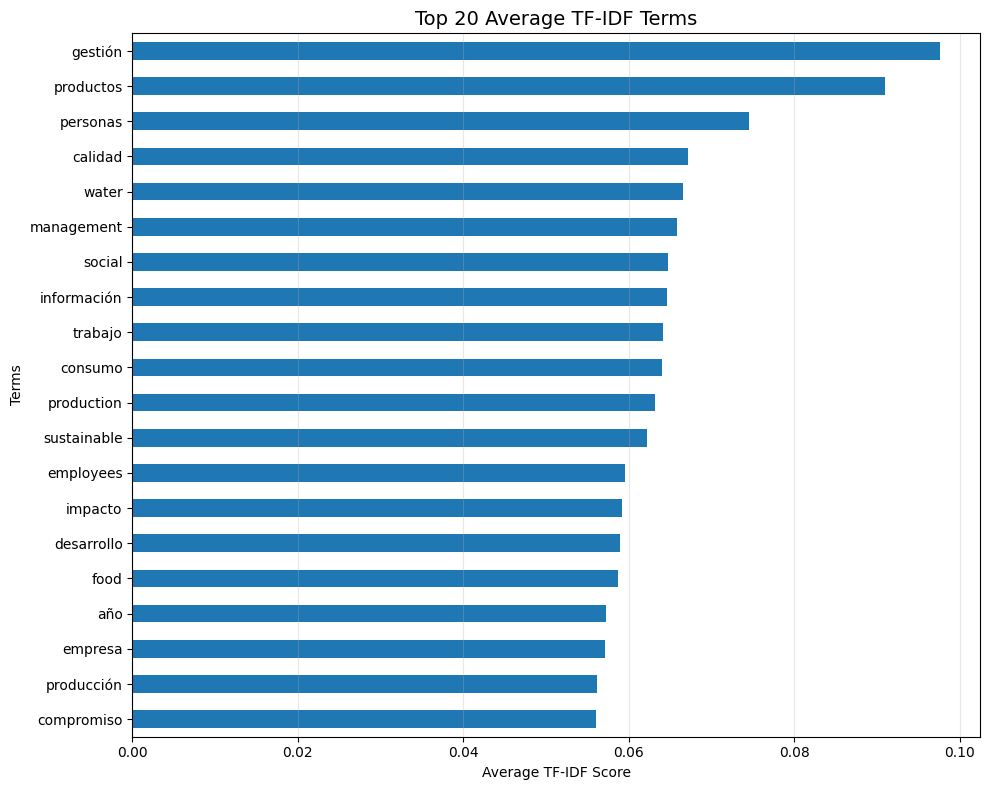

In [39]:
import matplotlib.pyplot as plt

top_tfidf = mean_tfidf.head(20)

plt.figure(figsize=(10,8))

top_tfidf.sort_values().plot(kind="barh")

plt.title("Top 20 Average TF-IDF Terms", fontsize=14)
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Terms")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation
The TF-IDF analysis highlights the most representative terms across the sustainability reports. Terms such as gestión, productos, personas, calidad, and water receive the highest scores, indicating that environmental management, product responsibility, quality, and stakeholder-related topics are key themes within the analyzed documents.



# 13. Topic Modeling (LDA)

## Objective

Topic Modeling is an unsupervised Natural Language Processing technique that automatically identifies the main themes discussed within a collection of documents. In this project, Latent Dirichlet Allocation (LDA) is applied to discover the dominant sustainability topics appearing across the sustainability reports.

In [40]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Create the document-term matrix
vectorizer = CountVectorizer(
    max_features=1000,
    min_df=2,          # Ignore very rare words
    max_df=0.90        # Ignore extremely common words
)

dtm = vectorizer.fit_transform(documents_df["Clean_Text"])

# Train the LDA model
lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(dtm)

LatentDirichletAllocation(n_components=5, random_state=42)

In [41]:
words = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):

    print(f"\nTopic {topic_idx + 1}")

    top_words = [
        words[i]
        for i in topic.argsort()[-10:][::-1]
    ]

    print(", ".join(top_words))


Topic 1
sca, formación, tel, dcoop, empresa, aceite, gestión, trabajo, arias, personal

Topic 2
water, management, impact, food, chain, employees, people, emissions, sustainable, safety

Topic 3
production, organic, sugar, director, plant, food, quality, spain, without, productos

Topic 4
gestión, información, productos, personas, consumo, calidad, impacto, seguridad, compromiso, trabajo

Topic 5
alimentos, organisation, according, vida, family, des, acción, united, emissions, way


### Interpretation

Interpretation

The LDA model identifies five main topics discussed across the sustainability reports. The extracted keywords indicate that the reports mainly focus on environmental management, social responsibility, product quality, resource management, and corporate governance, highlighting the dominant sustainability themes within the dataset.

# 13. Topic Modeling (LDA)

## Objective

Sentiment analysis evaluates the overall emotional tone of the sustainability reports by assigning a polarity score to each document. This analysis provides an overview of whether the reports use predominantly positive, neutral, or negative language.

In [43]:
!pip install textblob

In [44]:
from textblob import TextBlob

# Calculate sentiment polarity
documents_df["Sentiment"] = documents_df["Text"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

documents_df[["Company", "Sentiment"]].head()

,Company,Sentiment
0,certificados-iberfruta-2025,0.086124
1,sus rapport company uvesa,0.000000
2,sus report famadesa,0.000000
3,sus report company sovena,0.102645
4,sus report company capsa,0.011753


In [45]:
documents_df["Sentiment"].describe()

,Sentiment
count,126.000000
mean,0.059877
std,0.069394
min,-0.123433
25%,0.000000
50%,0.054706
75%,0.108097
max,0.250000


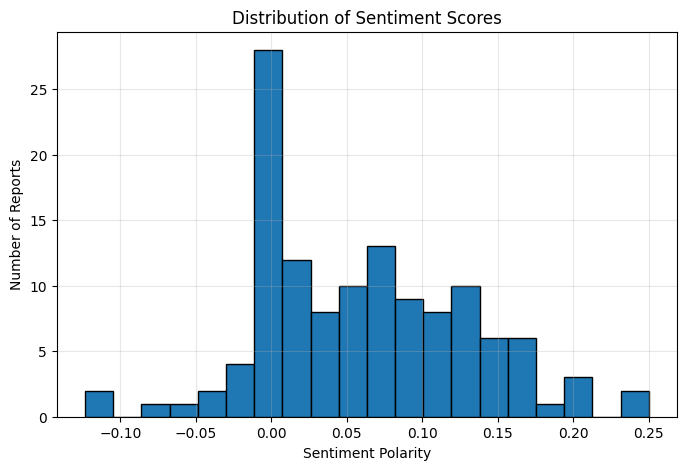

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(documents_df["Sentiment"], bins=20, edgecolor="black")

plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Number of Reports")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

Interpretation

The sentiment analysis indicates the overall tone of the sustainability reports. Most reports present neutral to moderately positive sentiment, reflecting the formal and informative language typically used in corporate sustainability disclosures.

### 15. ESG Keyword Analysis

#### Objective

This analysis examines the frequency of key Environmental, Social, and Governance (ESG) terms across the sustainability reports. By identifying how often ESG-related concepts are mentioned, it provides an overview of the sustainability topics that receive the greatest emphasis within the document collection. The analysis complements the previous NLP techniques by focusing specifically on sustainability-related terminology.



In [47]:
# ESG keywords
esg_keywords = [
    # Environmental
    "climate", "carbon", "emissions", "energy", "water",
    "waste", "biodiversity", "environment", "renewable",
    "recycling", "circular", "pollution",

    # Social
    "employees", "people", "community", "health",
    "safety", "human", "diversity", "training",
    "education", "labour", "rights",

    # Governance
    "governance", "board", "ethics", "compliance",
    "risk", "transparency", "audit", "stakeholder"
]

In [48]:
from collections import Counter

all_words = " ".join(documents_df["Clean_Text"]).split()

word_counts = Counter(all_words)

esg_counts = {
    word: word_counts[word]
    for word in esg_keywords
    if word_counts[word] > 0
}

esg_df = (
    pd.DataFrame(
        esg_counts.items(),
        columns=["Keyword", "Frequency"]
    )
    .sort_values("Frequency", ascending=False)
)

esg_df

,Keyword,Frequency
4,water,3354
12,employees,2410
13,people,2221
2,emissions,2200
16,safety,2083
15,health,1991
27,risk,1976
0,climate,1911
22,rights,1827
17,human,1670


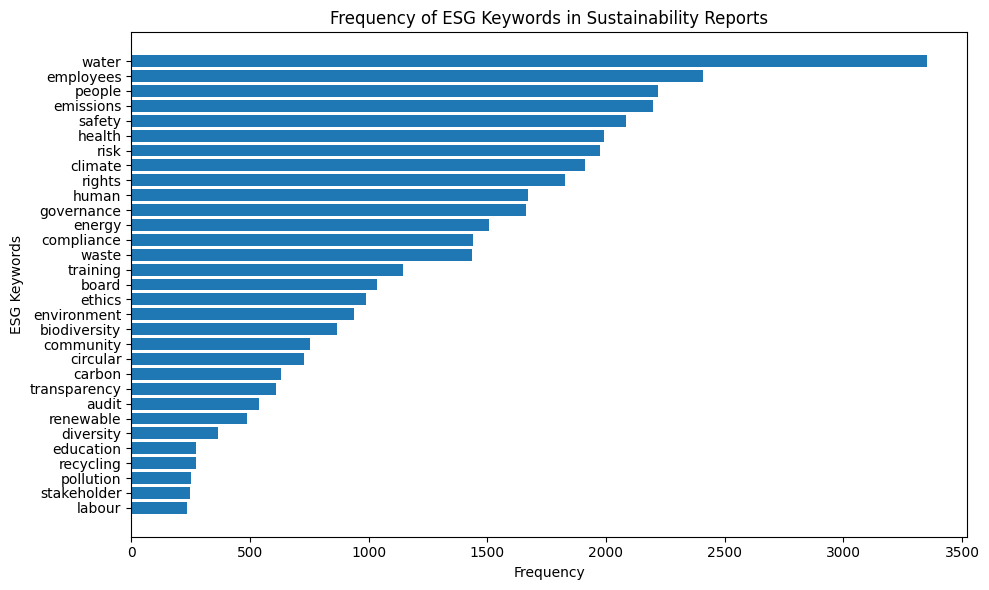

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    esg_df["Keyword"],
    esg_df["Frequency"]
)

plt.xlabel("Frequency")
plt.ylabel("ESG Keywords")
plt.title("Frequency of ESG Keywords in Sustainability Reports")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

#### Interpretation

The ESG keyword analysis indicates that environmental, social, and governance concepts are widely discussed across the sustainability reports. Environmental topics such as **water**, **emissions**, and **energy**, together with social themes including **employees** and **safety**, are among the most frequently mentioned, reflecting the strong emphasis companies place on sustainable environmental management, employee well-being, and responsible corporate governance.

## 16. Summary of Findings

### Objective

This section summarizes the main findings obtained from the Natural Language Processing analyses conducted on the sustainability reports.

#### Summary

- A total of 126 sustainability reports were processed.
- Text preprocessing successfully cleaned the extracted corpus.
- Environmental and social topics were the most frequently discussed themes.
- TF-IDF highlighted representative terms across individual reports.
- Topic Modeling identified five dominant sustainability themes.
- Sentiment analysis showed that most reports use neutral language.
- ESG keyword analysis confirmed a strong emphasis on environmental management, employees, governance, and responsible business practices.

Overall, the NLP analyses provide a comprehensive overview of the main sustainability topics discussed across the collected reports.